In [40]:
from sage.all import *
preparser(False)

In [41]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scipy yfinance pandas_datareader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as sp_norm
from scipy.optimize import brentq
import yfinance as yf
from datetime import datetime

In [45]:
def bs_call(s, k, t, r, sigma):
    d1=(np.log(s/k)+(r+0.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2=d1-sigma*np.sqrt(t)
    return s*sp_norm.cdf(d1)-k*np.exp((-1)*r*t)*sp_norm.cdf(d2)

def bs_putt(s, k, t, r, sigma):
    d1=(np.log(s/k)+(r+0.5*sigma**2)*t)/(sigma*np.sqrt(t))
    d2=d1-sigma*sp_np.sqrt(t)
    return k*sp_np.exp((-1)*r*t)*sp_norm.cdf((-1)*d2)-s*sp_norm.cdf((-1)*d1)

In [46]:
def bs_call_greeks(s, k, t, r, sigma):
    d1 = (np.log(s/k) + (r + 0.5*sigma**2)*t) / (sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)
    phi = sp_norm.pdf(d1)
    N1, N2 = sp_norm.cdf(d1), sp_norm.cdf(d2)
    
    price = s*N1 - k*np.exp(-r*t)*N2
    delta = N1
    gamma = phi / (s*sigma*np.sqrt(t))
    vega  = s*phi*np.sqrt(s)
    theta = -s*phi*sigma/(2*np.sqrt(t)) - r*k*np.exp(-r*t)*N2
    rho   = k*t*np.exp(-r*t)*N2
    
    return {
        'price': price, 'delta': delta, 'gamma': gamma,
        'vega': vega, 'theta': theta, 'rho': rho,
        'vega_per_1pct': vega/100,
        'theta_per_day': theta/365,
        'rho_per_1pct':  rho/100,
    }

g = bs_call_greeks(100, 100, 1.0, 0.05, 0.2)
for k, v in g.items():
    print(f"{k:>15}: {v:10.6f}")

          price:  10.450584
          delta:   0.636831
          gamma:   0.018762
           vega: 375.240347
          theta:  -6.414028
            rho:  53.232482
  vega_per_1pct:   3.752403
  theta_per_day:  -0.017573
   rho_per_1pct:   0.532325


In [47]:
def finite_diff_check(s, k, t, r, sigma, h=1e-4):
    analytic = bs_call_greeks(s, k, t, r, sigma)
    
    delta_fd = (bs_call(s+h, k, t, r, sigma) - bs_call(s-h, k, t, r, sigma)) / (2*h)
    gamma_fd = (bs_call(s+h, k, t, r, sigma) - 2*bs_call(s, k, t, r, sigma) 
                + bs_call(s-h, k, t, r, sigma)) / h**2
    vega_fd  = (bs_call(s, k, t, r, sigma+h) - bs_call(s, k, t, r, sigma-h)) / (2*h)
    theta_fd = (bs_call(s, k, t+h, r, sigma) - bs_call(s, k, t-h, r, sigma)) / (2*h)
    rho_fd   = (bs_call(s, k, t, r+h, sigma) - bs_call(s, k, t, r-h, sigma)) / (2*h)
    
    print(f"{'Greek':>8} {'Analytic':>12} {'Finite diff':>14} {'|diff|':>12}")
    for name, a, fd in [('delta', analytic['delta'], delta_fd),
                        ('gamma', analytic['gamma'], gamma_fd),
                        ('vega',  analytic['vega'],  vega_fd),
                        ('theta', analytic['theta'], theta_fd),
                        ('rho',   analytic['rho'],   rho_fd)]:
        print(f"{name:>8} {a:12.6f} {fd:14.6f} {abs(a-fd):12.2e}")

finite_diff_check(100, 100, 1.0, 0.05, 0.2)

   Greek     Analytic    Finite diff       |diff|
   delta     0.636831       0.636831     6.08e-12
   gamma     0.018762       0.018762     1.36e-07
    vega   375.240347      37.524034     3.38e+02
   theta    -6.414028       6.414028     1.28e+01
     rho    53.232482      53.232481     7.71e-07


In [48]:
ticker="SPY"
tk=yf.Ticker(ticker)
hist=yf.download(ticker, period="1y", auto_adjust=True)["Close"]
s0=float(hist.iloc[int(-1)].item())
print(f"Ціна{ticker}:${s0:.2f}")
logret=np.log(hist / hist.shift(int(1))).dropna()
sigma_hist=float(logret.std().item()*np.sqrt(252))
print(f"Історична σ:{sigma_hist*100:.2f}%")


[*********************100%***********************]  1 of 1 completed

ЦінаSPY:$708.60
Історична σ:12.87%


In [49]:
expiries=tk.options
print("Доступні експірації:", expiries[:10])
expiry=expiries[8]
t= float((pd.Timestamp(expiry)-pd.Timestamp.today()).days/365)
print(f"Обрана експірація:{expiry}, t={t:.4f} років")
chain=tk.option_chain(expiry)
calls=chain.calls.copy()
calls['mid']=(calls['bid']+calls['ask'])/2
calls=calls[calls['mid']>0]
calls[['strike', 'bid', 'ask', 'mid', 'volume', 'impliedVolatility']].head(10)

Доступні експірації: ('2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01')
Обрана експірація:2026-04-30, t=0.0247 років


,strike,bid,ask,mid,volume,impliedVolatility
0,430.0,277.06,279.86,278.460,1.0,1.458499
1,435.0,272.02,274.82,273.420,1.0,1.421390
2,445.0,262.09,264.89,263.490,2.0,1.375491
3,450.0,259.53,262.34,260.935,NaN,1.493167
4,460.0,249.53,252.35,250.940,1.0,1.431643
5,470.0,239.56,242.36,240.960,1.0,1.373050
6,475.0,234.55,237.37,235.960,1.0,1.342899
7,480.0,227.04,229.85,228.445,1.0,1.171879
8,485.0,224.58,227.38,225.980,2.0,1.285648
9,490.0,217.05,219.87,218.460,1.0,1.121098


In [50]:
try:
    from pandas_datareader import data as pdr
    r_series=pdr.DataReader("DGS3MO", "fred", start=pd.Timestamp.today()-pd.Timedelta(days=30))
    r=float(r_series.dropna().iloc[-1].item())/100
except Exception as e:
    print(f"FRED недоступний ({e}), використовуємо дефолт")
    r=0.045
print(f"r={r*100:.3f}%")

FRED недоступний (deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'), використовуємо дефолт
r=4.500%


In [58]:
results = []
for _, row in calls.iterrows():
    k = row['strike']
    bs_price = bs_call(s0, k, t, r, sigma_hist)
    results.append({
        'strike': k,
        'moneyness': k/s0,
        'market_mid': row['mid'],
        'bs_price': bs_price,
        'diff': bs_price - row['mid'],
        'market_iv': row['impliedVolatility'],
    })

comp = pd.DataFrame(results)
comp = comp[(comp['moneyness'] > 0.9) & (comp['moneyness'] < 1.1)]
comp.round(4)

,strike,moneyness,market_mid,bs_price,diff,market_iv
67,638.0,0.9004,70.905,71.3075,0.4025,0.3179
68,639.0,0.9018,69.825,70.3086,0.4836,0.3027
69,640.0,0.9032,68.875,69.3097,0.4347,0.3059
70,641.0,0.9046,67.835,68.3108,0.4758,0.2964
71,642.0,0.9060,66.865,67.3119,0.4469,0.2966
...,...,...,...,...,...,...
180,755.0,1.0655,0.055,0.0042,-0.0508,0.1548
181,760.0,1.0725,0.045,0.0012,-0.0438,0.1650
182,765.0,1.0796,0.045,0.0003,-0.0447,0.1787
183,770.0,1.0866,0.035,0.0001,-0.0349,0.1875


In [61]:
def implied_vol(c_market, s, k, t, r):
    c_market = float(c_market)
    s, k, t, r = float(s), float(k), float(t), float(r)
    try:
        return brentq(lambda aaaa: bs_call(s, k, t, r, aaaa) - c_market, 
                      float(1e-6), float(5.0), xtol=float(1e-8))
    except (ValueError, RuntimeError):
        return float('nan')

comp['iv_computed'] = comp.apply(
    lambda row: implied_vol(row['market_mid'], s0, row['strike'], t, r), axis=1
)
comp[['strike', 'moneyness', 'market_mid', 'bs_price', 'iv_computed']].round(4)

,strike,moneyness,market_mid,bs_price,iv_computed
67,638.0,0.9004,70.905,71.3075,NaN
68,639.0,0.9018,69.825,70.3086,NaN
69,640.0,0.9032,68.875,69.3097,NaN
70,641.0,0.9046,67.835,68.3108,NaN
71,642.0,0.9060,66.865,67.3119,NaN
...,...,...,...,...,...
180,755.0,1.0655,0.055,0.0042,0.1666
181,760.0,1.0725,0.045,0.0012,0.1777
182,765.0,1.0796,0.045,0.0003,0.1925
183,770.0,1.0866,0.035,0.0001,0.2014


In [62]:
print(comp.columns.tolist())

['strike', 'moneyness', 'market_mid', 'bs_price', 'diff', 'market_iv', 'iv_computed']


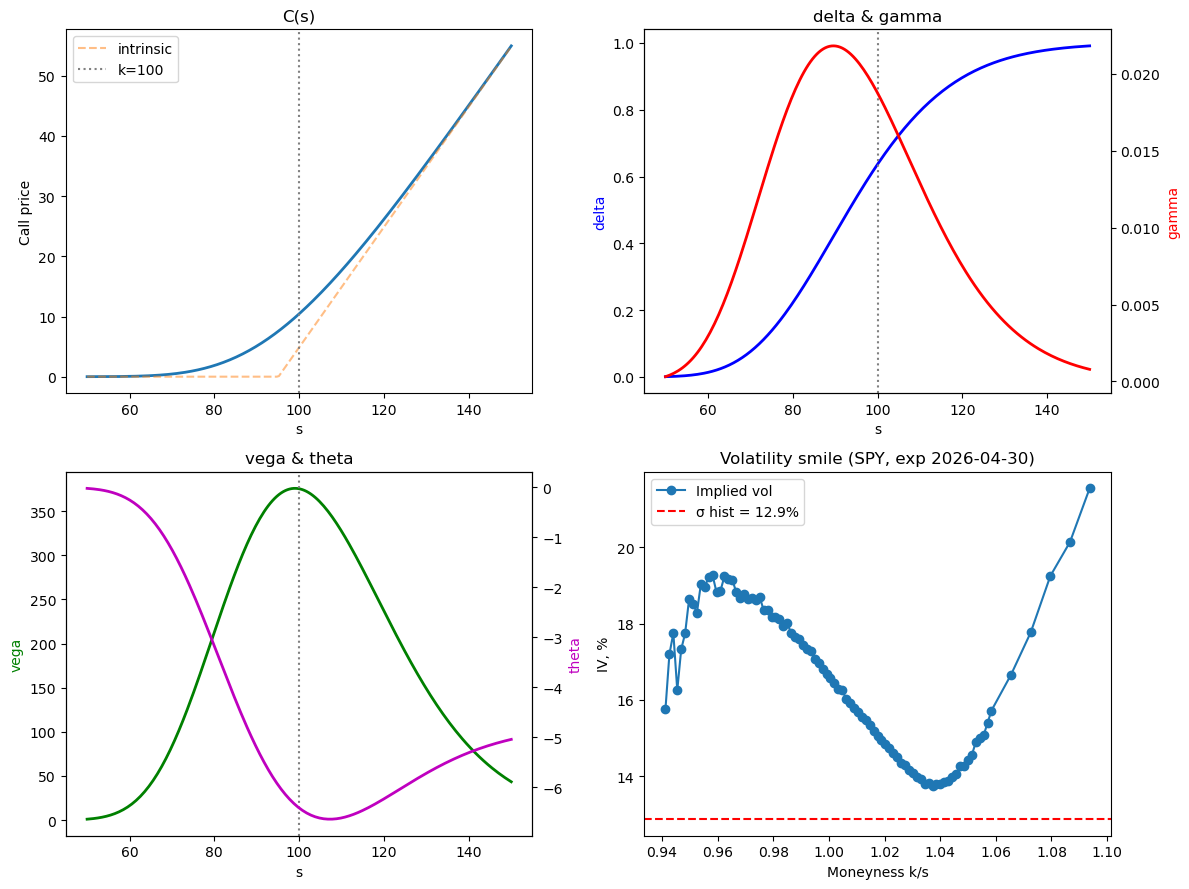

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

s_range = np.linspace(50, 150, 200)
k_, t_, r_, s_ = 100, 1.0, 0.05, 0.2


axes[0,0].plot(s_range, [bs_call(s, k_, t_, r_, s_) for s in s_range], lw=2)
axes[0,0].plot(s_range, np.maximum(s_range - k_*np.exp(-r_*t_), 0), 
               '--', alpha=0.5, label='intrinsic')
axes[0,0].axvline(k_, color='gray', ls=':', label=f'k={k_}')
axes[0,0].set_xlabel('s'); axes[0,0].set_ylabel('Call price')
axes[0,0].set_title('C(s)'); axes[0,0].legend()

deltas = [bs_call_greeks(s, k_, t_, r_, s_)['delta'] for s in s_range]
gammas = [bs_call_greeks(s, k_, t_, r_, s_)['gamma'] for s in s_range]
ax2 = axes[0,1]; ax2b = ax2.twinx()
ax2.plot(s_range, deltas, 'b-', lw=2, label='delta')
ax2b.plot(s_range, gammas, 'r-', lw=2, label='gamma')
ax2.set_xlabel('s'); ax2.set_ylabel('delta', color='b')
ax2b.set_ylabel('gamma', color='r')
ax2.axvline(k_, color='gray', ls=':')
ax2.set_title('delta & gamma')


vegas  = [bs_call_greeks(s, k_, t_, r_, s_)['vega']  for s in s_range]
thetas = [bs_call_greeks(s, k_, t_, r_, s_)['theta'] for s in s_range]
ax3 = axes[1,0]; ax3b = ax3.twinx()
ax3.plot(s_range, vegas, 'g-', lw=2, label='Vega')
ax3b.plot(s_range, thetas, 'm-', lw=2, label='Theta')
ax3.set_xlabel('s'); ax3.set_ylabel('vega', color='g')
ax3b.set_ylabel('theta', color='m')
ax3.axvline(k_, color='gray', ls=':')
ax3.set_title('vega & theta')

axes[1,1].plot(comp['moneyness'], comp['iv_computed']*100, 'o-', label='Implied vol')
axes[1,1].axhline(sigma_hist*100, color='red', ls='--', label=f'σ hist = {sigma_hist*100:.1f}%')
axes[1,1].set_xlabel('Moneyness k/s'); axes[1,1].set_ylabel('IV, %')
axes[1,1].set_title(f'Volatility smile ({ticker}, exp {expiry})')
axes[1,1].legend()

plt.tight_layout()
plt.show()